In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#load dataset

In [4]:
housing = fetch_california_housing()

print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [5]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [6]:
#Convert to Pandas DataFrame

In [7]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
#Understand the Dataset

In [10]:
df.shape

(20640, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
#missing values

In [14]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [15]:
#Check Duplicate Values

In [16]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
20635,False
20636,False
20637,False
20638,False


In [17]:
df = df.drop_duplicates()

In [18]:
#Separate Features and Target

In [19]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [21]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [22]:
#Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
#Feature Scaling

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
#Linear Regression

In [27]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [28]:
#Decision Tree Regressor

In [29]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [30]:
#Random Forest Regressor

In [31]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [32]:
#Gradient Boosting Regressor

In [33]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [34]:
#Support Vector Regressor

In [35]:
svr = SVR(kernel="rbf")

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

In [36]:
#Evaluate the Models

In [37]:
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, mae, r2

In [38]:
results = []

models_predictions = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "SVR": y_pred_svr
}

for model_name, predictions in models_predictions.items():

    mse, mae, r2 = evaluate_model(y_test, predictions)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    })

In [40]:
results_df = pd.DataFrame(results)

results_df

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


In [43]:
#Model Comparison Visualization

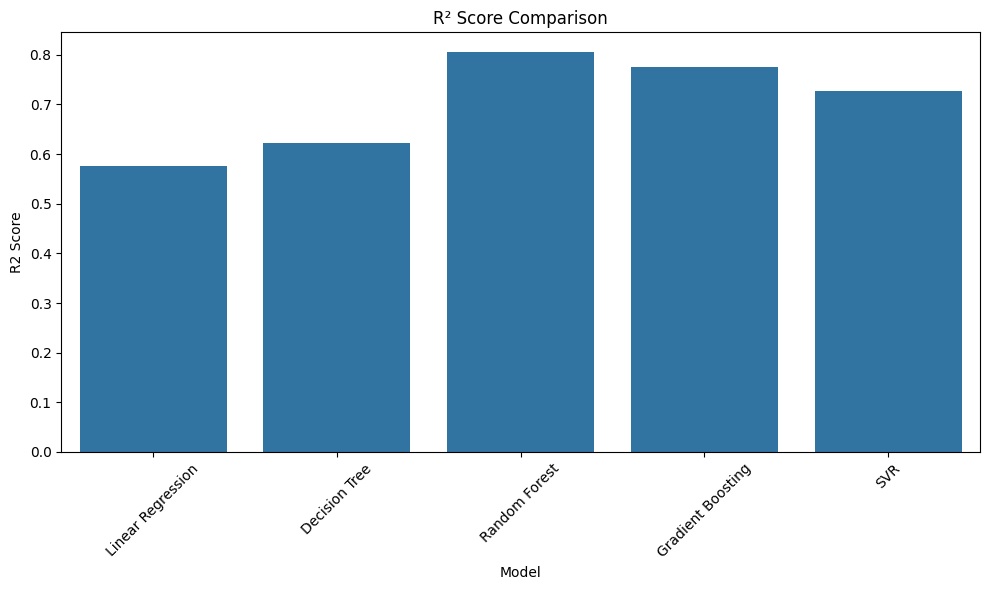

In [44]:
#R² Comparison
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=45)
plt.title("R² Score Comparison")
plt.tight_layout()
plt.show()

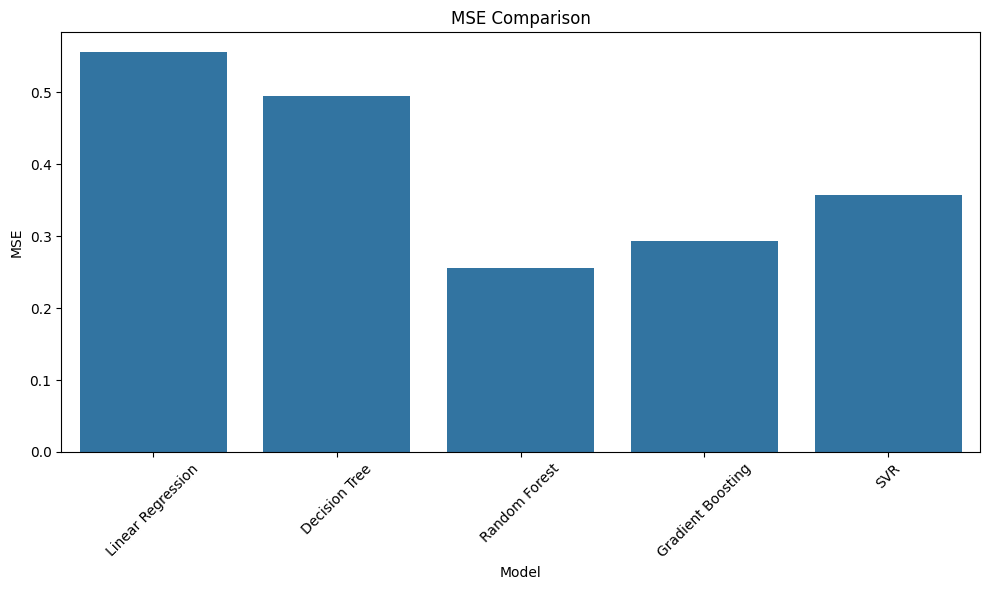

In [45]:
#MSE Comparison
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="MSE"
)

plt.xticks(rotation=45)
plt.title("MSE Comparison")
plt.tight_layout()
plt.show()

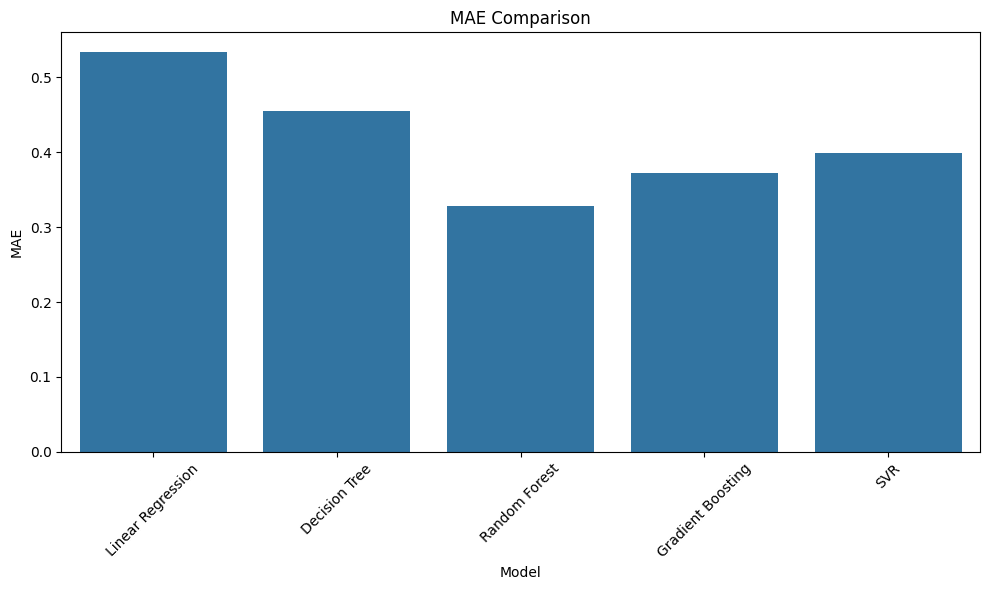

In [46]:
#MAE Comparison
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE"
)

plt.xticks(rotation=45)
plt.title("MAE Comparison")
plt.tight_layout()
plt.show()

### Model Comparison

After evaluating all five regression algorithms using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R²), the models were compared based on their predictive performance.

The **Random Forest Regressor** performed the best among the evaluated models because it achieved the highest R² score and comparatively lower MSE and MAE. Random Forest is well suited to the California Housing dataset because it can capture nonlinear relationships between housing features and house prices and can combine predictions from multiple decision trees to improve generalization.

The **worst-performing model** was identified based on its lowest R² score and comparatively higher error values. Its weaker performance suggests that it was less capable of capturing the complex relationships present in the California Housing data.

Overall, the comparison demonstrates that ensemble tree-based methods can perform strongly on this regression problem because housing prices are influenced by nonlinear interactions between multiple features.
